In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels prophet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [8]:
df = pd.read_csv("burnot_cleann.csv")

In [9]:
df.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,30-09-2008,Female,Service,No,2,3,3.8,0.16
1,fffe3700360033003500,30-11-2008,Male,Service,Yes,1,2,5.0,0.36
2,fffe32003400380032003900,03-11-2008,Male,Service,Yes,1,1,2.6,0.20
3,fffe31003900340031003600,24-07-2008,Female,Service,No,3,7,6.9,0.52
4,fffe3300350037003500,26-11-2008,Male,Product,Yes,2,4,3.6,0.29


In [10]:
df.shape

(18590, 9)

In [11]:
df.columns

Index(['Employee ID', 'Date of Joining', 'Gender', 'Company Type',
       'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18590 entries, 0 to 18589
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           18590 non-null  object 
 1   Date of Joining       18590 non-null  object 
 2   Gender                18590 non-null  object 
 3   Company Type          18590 non-null  object 
 4   WFH Setup Available   18590 non-null  object 
 5   Designation           18590 non-null  int64  
 6   Resource Allocation   18590 non-null  int64  
 7   Mental Fatigue Score  18590 non-null  float64
 8   Burn Rate             18590 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 1.3+ MB


In [13]:
df.isnull().sum()

Employee ID             0
Date of Joining         0
Gender                  0
Company Type            0
WFH Setup Available     0
Designation             0
Resource Allocation     0
Mental Fatigue Score    0
Burn Rate               0
dtype: int64

In [14]:
df.describe()

,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
count,18590.000000,18590.000000,18590.000000,18590.000000
mean,2.179398,4.486552,5.732173,0.452444
std,1.133148,2.044848,1.920547,0.197848
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,4.600000,0.320000
50%,2.000000,4.000000,5.900000,0.450000
75%,3.000000,6.000000,7.100000,0.590000
max,5.000000,10.000000,10.000000,1.000000


In [15]:
df.duplicated().sum()

0

In [16]:
df.to_csv("Burnout_Phase2_Loaded.csv", index=False)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18590 entries, 0 to 18589
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           18590 non-null  object 
 1   Date of Joining       18590 non-null  object 
 2   Gender                18590 non-null  object 
 3   Company Type          18590 non-null  object 
 4   WFH Setup Available   18590 non-null  object 
 5   Designation           18590 non-null  int64  
 6   Resource Allocation   18590 non-null  int64  
 7   Mental Fatigue Score  18590 non-null  float64
 8   Burn Rate             18590 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 1.3+ MB


In [18]:
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])

C:\Users\rpere\AppData\Local\Temp\ipykernel_54020\3163426663.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date of Joining'] = pd.to_datetime(df['Date of Joining'])


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18590 entries, 0 to 18589
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Employee ID           18590 non-null  object        
 1   Date of Joining       18590 non-null  datetime64[ns]
 2   Gender                18590 non-null  object        
 3   Company Type          18590 non-null  object        
 4   WFH Setup Available   18590 non-null  object        
 5   Designation           18590 non-null  int64         
 6   Resource Allocation   18590 non-null  int64         
 7   Mental Fatigue Score  18590 non-null  float64       
 8   Burn Rate             18590 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 1.3+ MB


In [20]:
df['Date of Joining'] = pd.to_datetime(df['Date of Joining'], format='%d-%m-%Y')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18590 entries, 0 to 18589
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Employee ID           18590 non-null  object        
 1   Date of Joining       18590 non-null  datetime64[ns]
 2   Gender                18590 non-null  object        
 3   Company Type          18590 non-null  object        
 4   WFH Setup Available   18590 non-null  object        
 5   Designation           18590 non-null  int64         
 6   Resource Allocation   18590 non-null  int64         
 7   Mental Fatigue Score  18590 non-null  float64       
 8   Burn Rate             18590 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 1.3+ MB


In [22]:
df.columns = [
    'employee_id',
    'date_of_joining',
    'gender',
    'company_type',
    'wfh_setup',
    'designation',
    'resource_allocation',
    'mental_fatigue_score',
    'burn_rate'
]

In [23]:
df.columns

Index(['employee_id', 'date_of_joining', 'gender', 'company_type', 'wfh_setup',
       'designation', 'resource_allocation', 'mental_fatigue_score',
       'burn_rate'],
      dtype='object')

In [24]:
df.to_csv("Burnout_Phase2_Final.csv", index=False)

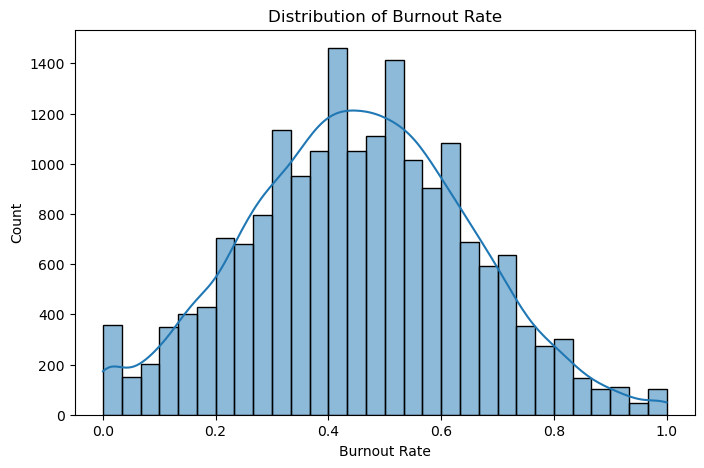

Burnout Rate Summary:
count    18590.000000
mean         0.452444
std          0.197848
min          0.000000
25%          0.320000
50%          0.450000
75%          0.590000
max          1.000000
Name: burn_rate, dtype: float64


In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df['burn_rate'], bins=30, kde=True)
plt.title("Distribution of Burnout Rate")
plt.xlabel("Burnout Rate")
plt.ylabel("Count")
plt.show()

print("Burnout Rate Summary:")
print(df['burn_rate'].describe())

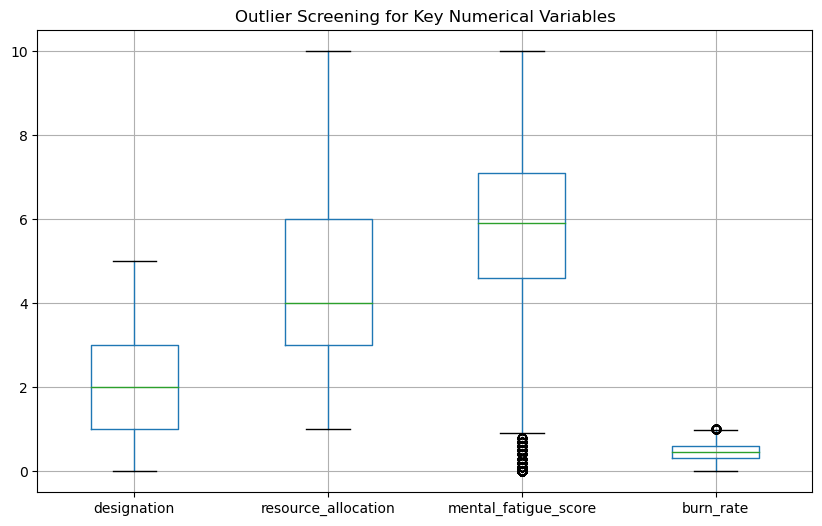

In [26]:
num_cols = ['designation', 'resource_allocation', 'mental_fatigue_score', 'burn_rate']

plt.figure(figsize=(10,6))
df[num_cols].boxplot()
plt.title("Outlier Screening for Key Numerical Variables")
plt.show()

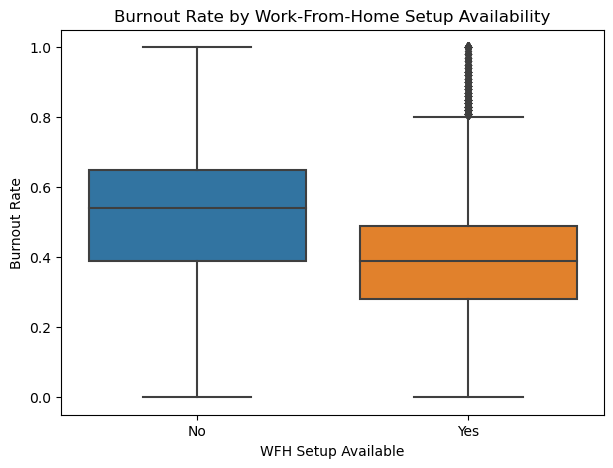

In [27]:
plt.figure(figsize=(7,5))
sns.boxplot(x='wfh_setup', y='burn_rate', data=df)
plt.title("Burnout Rate by Work-From-Home Setup Availability")
plt.xlabel("WFH Setup Available")
plt.ylabel("Burnout Rate")
plt.show()

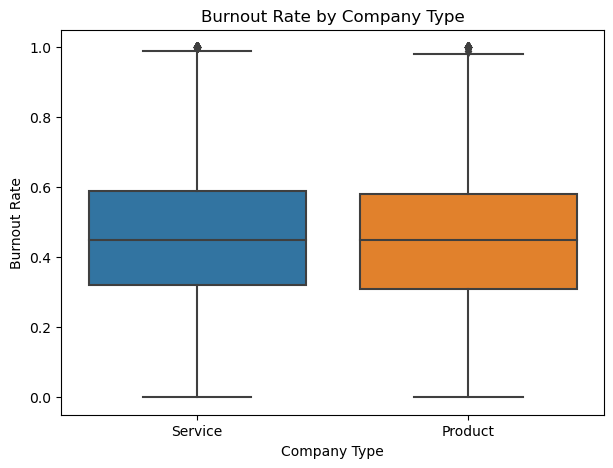

In [28]:
plt.figure(figsize=(7,5))
sns.boxplot(x='company_type', y='burn_rate', data=df)
plt.title("Burnout Rate by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Burnout Rate")
plt.show()

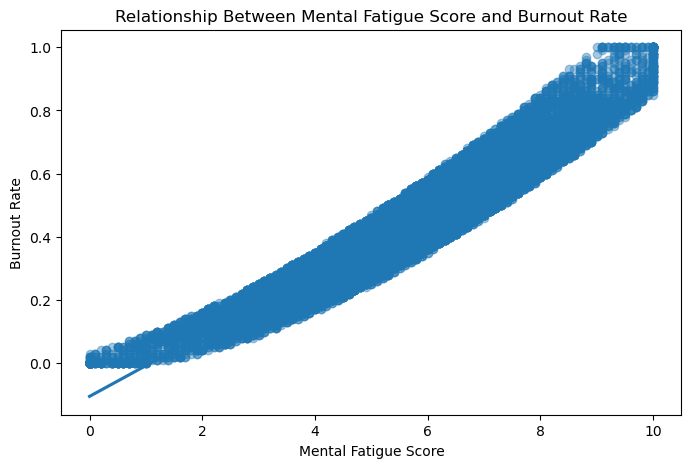

In [29]:
plt.figure(figsize=(8,5))
sns.regplot(x='mental_fatigue_score', y='burn_rate', data=df, scatter_kws={'alpha':0.4})
plt.title("Relationship Between Mental Fatigue Score and Burnout Rate")
plt.xlabel("Mental Fatigue Score")
plt.ylabel("Burnout Rate")
plt.show()

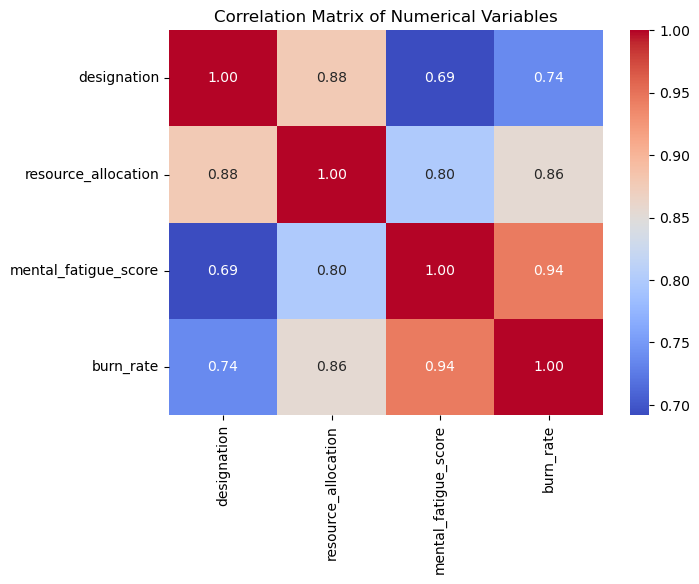

In [30]:
corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

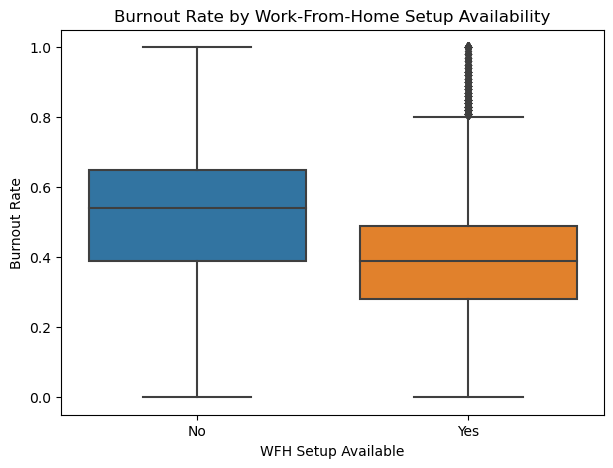

In [31]:
plt.figure(figsize=(7,5))
sns.boxplot(x='wfh_setup', y='burn_rate', data=df)
plt.title("Burnout Rate by Work-From-Home Setup Availability")
plt.xlabel("WFH Setup Available")
plt.ylabel("Burnout Rate")
plt.show()

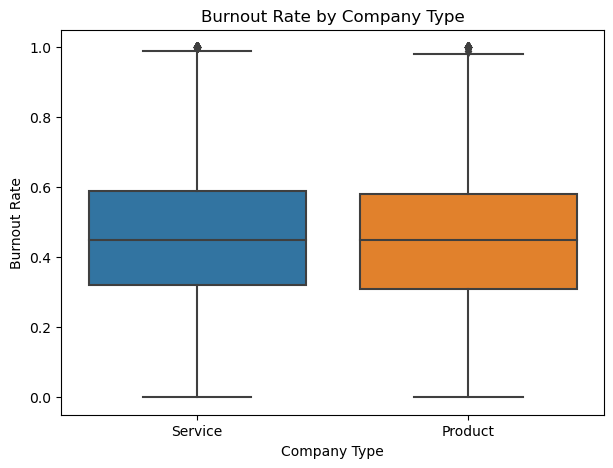

In [32]:
plt.figure(figsize=(7,5))
sns.boxplot(x='company_type', y='burn_rate', data=df)
plt.title("Burnout Rate by Company Type")
plt.xlabel("Company Type")
plt.ylabel("Burnout Rate")
plt.show()

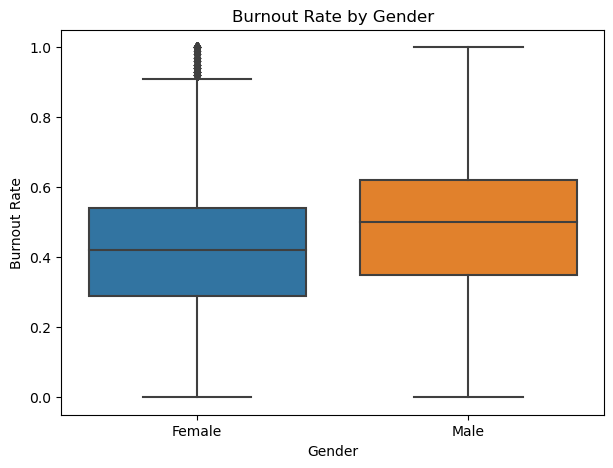

In [33]:
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='burn_rate', data=df)
plt.title("Burnout Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Burnout Rate")
plt.show()

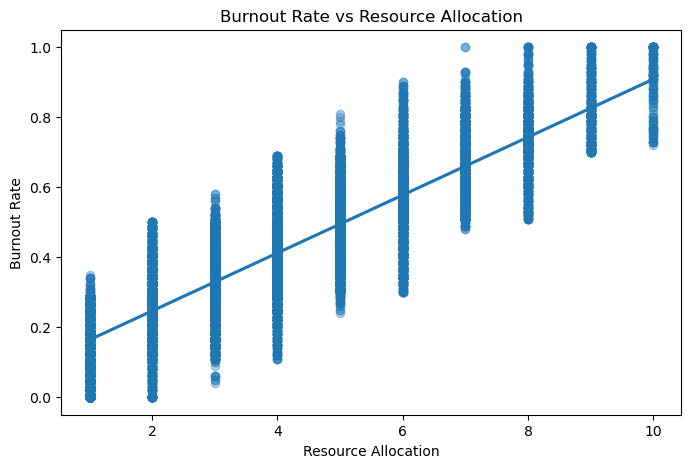

In [34]:
plt.figure(figsize=(8,5))
sns.regplot(x='resource_allocation', y='burn_rate', data=df, scatter_kws={'alpha':0.35})
plt.title("Burnout Rate vs Resource Allocation")
plt.xlabel("Resource Allocation")
plt.ylabel("Burnout Rate")
plt.show()

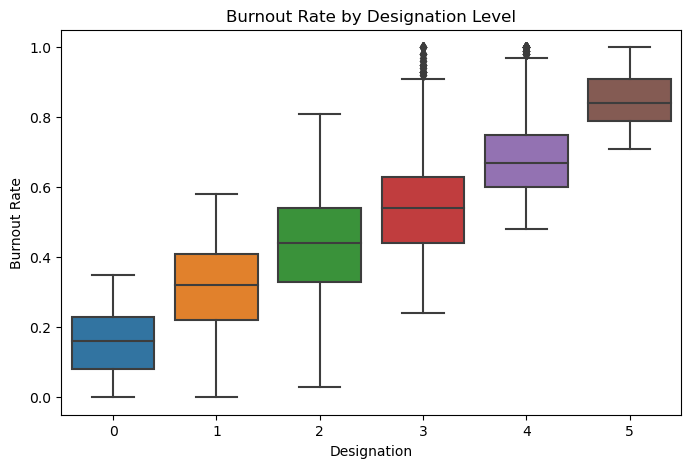

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='designation', y='burn_rate', data=df)
plt.title("Burnout Rate by Designation Level")
plt.xlabel("Designation")
plt.ylabel("Burnout Rate")
plt.show()

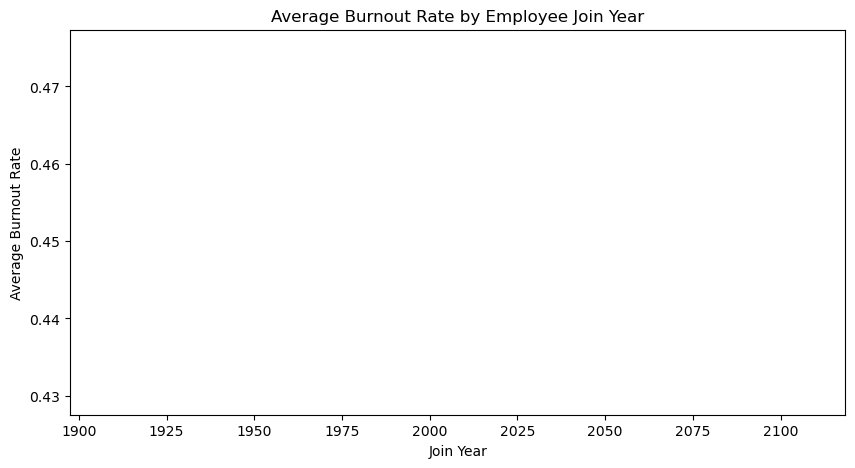

In [36]:
df['join_year'] = df['date_of_joining'].dt.year
df['join_month'] = df['date_of_joining'].dt.month

plt.figure(figsize=(10,5))
sns.lineplot(x='join_year', y='burn_rate', data=df, estimator='mean', errorbar=None)
plt.title("Average Burnout Rate by Employee Join Year")
plt.xlabel("Join Year")
plt.ylabel("Average Burnout Rate")
plt.show()

In [37]:
df['join_year'].value_counts().sort_index()

2008    18590
Name: join_year, dtype: int64

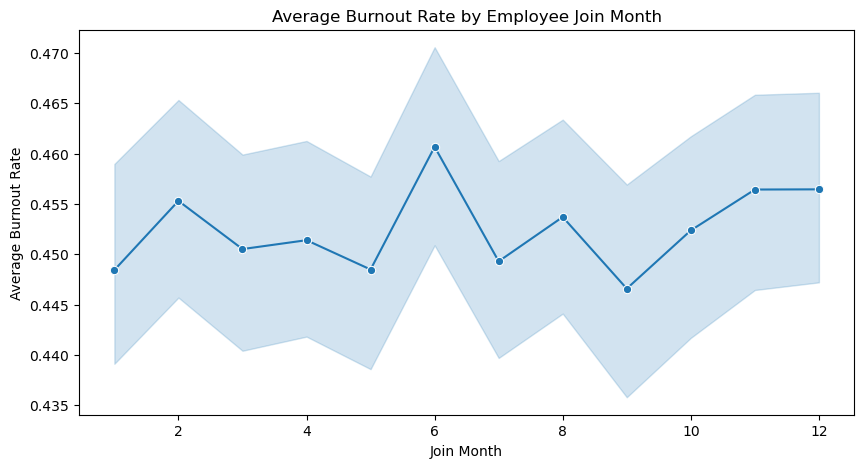

In [38]:
df['join_month'] = df['date_of_joining'].dt.month

plt.figure(figsize=(10,5))
sns.lineplot(x='join_month', y='burn_rate', data=df, estimator='mean', marker='o')
plt.title("Average Burnout Rate by Employee Join Month")
plt.xlabel("Join Month")
plt.ylabel("Average Burnout Rate")
plt.show()

In [39]:
df['join_year'] = df['date_of_joining'].dt.year
df['join_month'] = df['date_of_joining'].dt.month
df['join_day'] = df['date_of_joining'].dt.day
df['join_weekday'] = df['date_of_joining'].dt.weekday

In [40]:
df['fatigue_x_allocation'] = df['mental_fatigue_score'] * df['resource_allocation']

df['fatigue_x_designation'] = df['mental_fatigue_score'] * df['designation']

df['allocation_x_designation'] = df['resource_allocation'] * df['designation']

df['workload_index'] = (
    df['mental_fatigue_score'] +
    df['resource_allocation'] +
    df['designation']
)

In [41]:
df['fatigue_squared'] = df['mental_fatigue_score'] ** 2

df['allocation_squared'] = df['resource_allocation'] ** 2

df['designation_squared'] = df['designation'] ** 2

In [42]:
df['fatigue_high_flag'] = (df['mental_fatigue_score'] >= 7).astype(int)

df['allocation_high_flag'] = (df['resource_allocation'] >= 7).astype(int)

df['senior_flag'] = (df['designation'] >= 4).astype(int)

In [43]:
df_encoded = pd.get_dummies(df, columns=[
    'gender',
    'company_type',
    'wfh_setup'
], drop_first=True)

In [44]:
df_encoded = df_encoded.drop(columns=[
    'employee_id',
    'date_of_joining'
])

In [45]:
X = df_encoded.drop(columns=['burn_rate'])

y = df_encoded['burn_rate']

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
print("Total features:", X.shape[1])

Total features: 20


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np
import pandas as pd

In [49]:
def evaluate_regression(model, X_train, X_test, y_train, y_test, model_name="Model"):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [50]:
lr = LinearRegression()
lr_results = evaluate_regression(lr, X_train, X_test, y_train, y_test, "Linear Regression")
lr_results

{'Model': 'Linear Regression',
 'MAE': 0.04452085970384252,
 'RMSE': 0.05404382429099379,
 'R2': 0.9239486736455371}

In [51]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    n_jobs=-1
)

rf_results = evaluate_regression(rf, X_train, X_test, y_train, y_test, "Random Forest")
rf_results

{'Model': 'Random Forest',
 'MAE': 0.04455688057668826,
 'RMSE': 0.0554770050437424,
 'R2': 0.9198616011906275}

In [52]:
gbr = GradientBoostingRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)

gbr_results = evaluate_regression(gbr, X_train, X_test, y_train, y_test, "Gradient Boosting")
gbr_results

{'Model': 'Gradient Boosting',
 'MAE': 0.04327512798836826,
 'RMSE': 0.052867550183555684,
 'R2': 0.9272231894904852}

In [53]:
results_df = pd.DataFrame([lr_results, rf_results, gbr_results])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.044521,0.054044,0.923949
1,Random Forest,0.044557,0.055477,0.919862
2,Gradient Boosting,0.043275,0.052868,0.927223


In [54]:
best_model = results_df.sort_values("RMSE").iloc[0]
best_model

Model    Gradient Boosting
MAE               0.043275
RMSE              0.052868
R2                0.927223
Name: 2, dtype: object

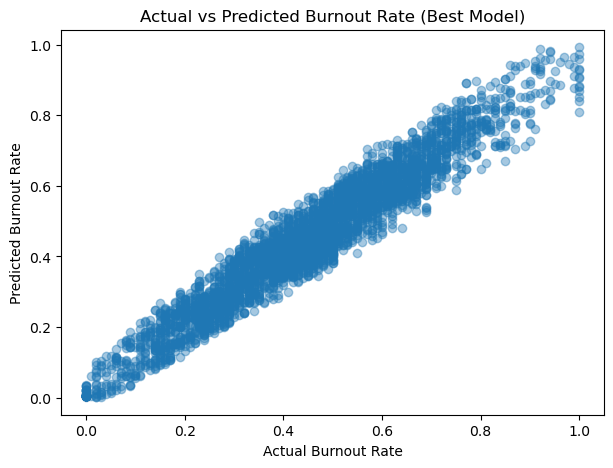

In [56]:
best = gbr
best.fit(X_train, y_train)
preds = best.predict(X_test)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_test, preds, alpha=0.4)
plt.title("Actual vs Predicted Burnout Rate (Best Model)")
plt.xlabel("Actual Burnout Rate")
plt.ylabel("Predicted Burnout Rate")
plt.show()

In [57]:
import joblib
joblib.dump(best, "best_burnout_regression_model.pkl")

['best_burnout_regression_model.pkl']

In [58]:
def classify_burnout(rate):
    if rate < 0.33:
        return "Low"
    elif rate < 0.66:
        return "Medium"
    else:
        return "High"

df_encoded['burnout_risk'] = df_encoded['burn_rate'].apply(classify_burnout)

df_encoded['burnout_risk'].value_counts()

Medium    10807
Low        4899
High       2884
Name: burnout_risk, dtype: int64

In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded['burnout_risk_encoded'] = le.fit_transform(df_encoded['burnout_risk'])

In [60]:
X_class = df_encoded.drop(columns=['burn_rate', 'burnout_risk', 'burnout_risk_encoded'])
y_class = df_encoded['burnout_risk_encoded']

In [61]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

clf.fit(X_train_c, y_train_c)

preds_c = clf.predict(X_test_c)

In [63]:
accuracy = accuracy_score(y_test_c, preds_c)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test_c, preds_c))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_c, preds_c))

Accuracy: 0.8762775685852608

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.75      0.78       569
           1       0.91      0.85      0.88       959
           2       0.88      0.92      0.90      2190

    accuracy                           0.88      3718
   macro avg       0.87      0.84      0.85      3718
weighted avg       0.88      0.88      0.88      3718


Confusion Matrix:
[[ 428    0  141]
 [   0  817  142]
 [  96   81 2013]]


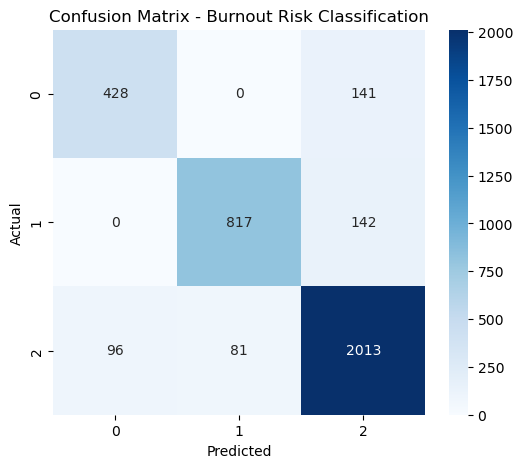

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_c, preds_c)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Burnout Risk Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
 ts = df.groupby('join_month')['burn_rate'].mean().reset_index()

ts.columns = ['month', 'burn_rate']

ts

,month,burn_rate
0,1,0.448433
1,2,0.455306
2,3,0.450516
3,4,0.451399
4,5,0.448485
...,...,...
7,8,0.453705
8,9,0.446584
9,10,0.452373
10,11,0.456434


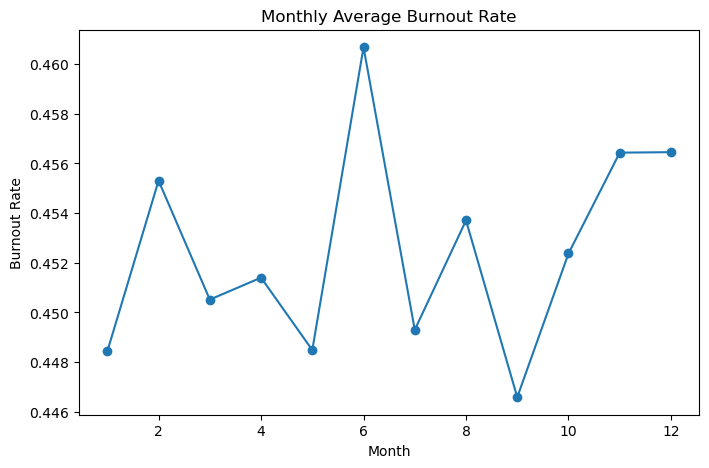

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(ts['month'], ts['burn_rate'], marker='o')
plt.title("Monthly Average Burnout Rate")
plt.xlabel("Month")
plt.ylabel("Burnout Rate")
plt.show()

In [67]:
pip install prophet

In [68]:
from prophet import Prophet

ts_prophet = ts.copy()

ts_prophet['ds'] = pd.date_range(start='2008-01-01', periods=len(ts_prophet), freq='M')

ts_prophet['y'] = ts_prophet['burn_rate']

ts_prophet = ts_prophet[['ds','y']]

ts_prophet

,ds,y
0,2008-01-31,0.448433
1,2008-02-29,0.455306
2,2008-03-31,0.450516
3,2008-04-30,0.451399
4,2008-05-31,0.448485
...,...,...
7,2008-08-31,0.453705
8,2008-09-30,0.446584
9,2008-10-31,0.452373
10,2008-11-30,0.456434


In [69]:
model = Prophet()

model.fit(ts_prophet)

19:05:25 - cmdstanpy - INFO - Chain [1] start processing
19:05:26 - cmdstanpy - INFO - Chain [1] done processing


In [71]:
future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2008-01-31,0.451216,0.446384,0.455884
1,2008-02-29,0.451365,0.446394,0.455969
2,2008-03-31,0.451525,0.446839,0.456376
3,2008-04-30,0.451680,0.446988,0.456463
4,2008-05-31,0.451840,0.447248,0.457043
...,...,...,...,...
13,2009-02-28,0.457173,0.452224,0.461538
14,2009-03-31,0.458140,0.453807,0.462789
15,2009-04-30,0.459077,0.454332,0.463768
16,2009-05-31,0.460044,0.455122,0.464342


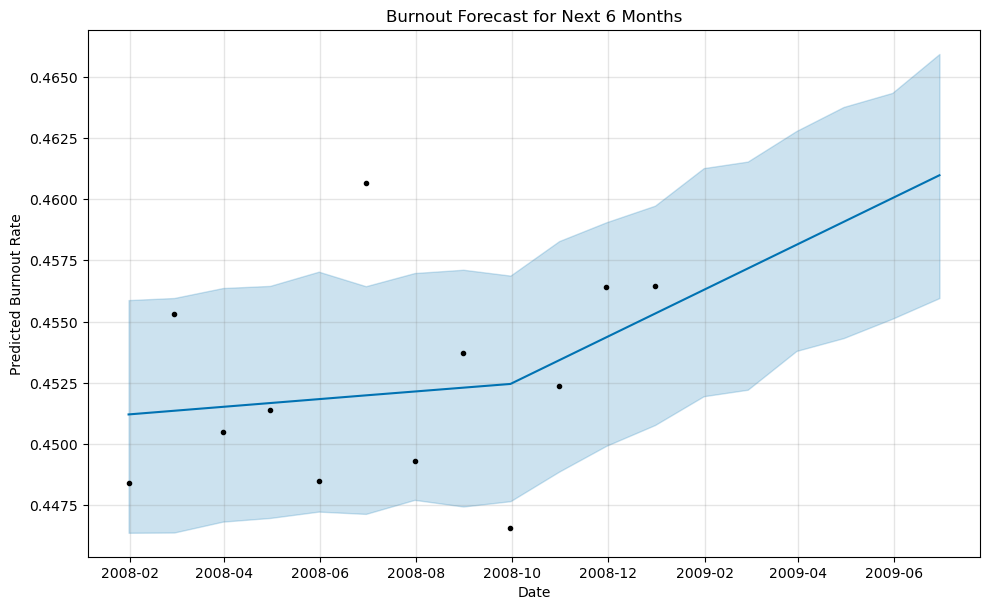

In [72]:
fig = model.plot(forecast)
plt.title("Burnout Forecast for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Predicted Burnout Rate")
plt.show()

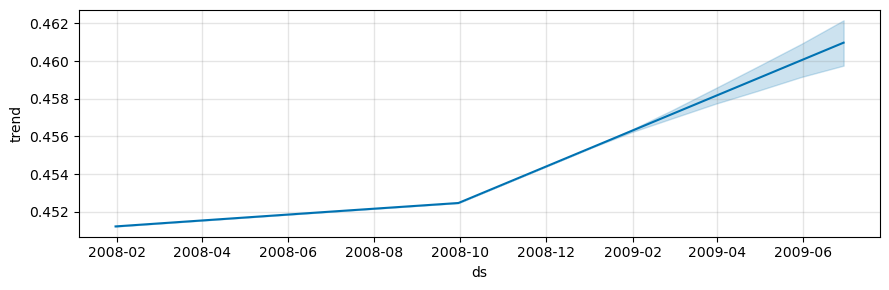

In [73]:
fig2 = model.plot_components(forecast)
plt.show()

In [74]:
future_forecast = forecast.tail(6)

future_forecast[['ds','yhat','yhat_lower','yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
12,2009-01-31,0.456299,0.451959,0.461271
13,2009-02-28,0.457173,0.452224,0.461538
14,2009-03-31,0.458140,0.453807,0.462789
15,2009-04-30,0.459077,0.454332,0.463768
16,2009-05-31,0.460044,0.455122,0.464342
17,2009-06-30,0.460980,0.455966,0.465933


In [75]:
from sklearn.ensemble import GradientBoostingRegressor

best = GradientBoostingRegressor(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3
)
best.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

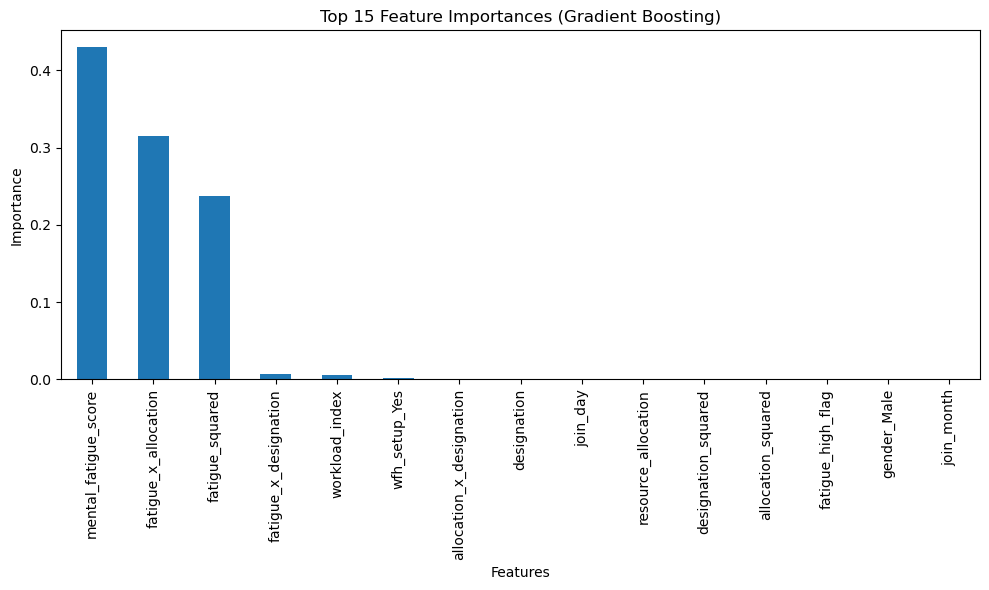

mental_fatigue_score     0.430139
fatigue_x_allocation     0.314587
fatigue_squared          0.237876
fatigue_x_designation    0.007296
workload_index           0.006161
                           ...   
join_weekday             0.000069
company_type_Service     0.000056
senior_flag              0.000048
allocation_high_flag     0.000017
join_year                0.000000
Length: 20, dtype: float64

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(best.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind="bar")
plt.title("Top 15 Feature Importances (Gradient Boosting)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

importances.head(20)

In [77]:
pip install shap

  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/77/03/58e199cf59056d68b4a227ce4b2b09eeb0c9bd1d002b9e28fb574eed6200/shap-0.50.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for numpy>=2 from https://files.pythonhosted.org/packages/76/ae/e0265e0163cf127c24c3969d29f1c4c64551a1e375d95a13d32eab25d364/numpy-2.4.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for slicer==0.0.8 from https://files.pythonhosted.org/packages/63/81/9ef641ff4e12cbcca30e54e72fb0951a2ba195d0cda0ba4100e532d929db/slicer-0.0.8-py3-none-any.whl.metadata
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
  Obtaining dependency information for numba>=0.54 from https://files.pythonhosted.org/packages/31/29/e09d5630578a50a2b3fa154990b6b839cf95327aa0709e2d50d0b6816cd1/numba-0.64.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency informatio

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\rpere\\anaconda3\\Lib\\site-packages\\~.learn\\.libs\\msvcp140.dll'
Consider using the `--user` option or check the permissions.



In [78]:
import shap
shap.initjs()

# Use TreeExplainer for tree models
explainer = shap.Explainer(best, X_train)
shap_values = explainer(X_test)

# Summary plot (global)
shap.summary_plot(shap_values, X_test, show=True)

ModuleNotFoundError: No module named 'shap'

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

In [ ]:
i = 1 # change to 1,2,3 if you want another employee
shap.plots.waterfall(shap_values[1])

In [79]:
import sys
!{sys.executable} -m pip install shap

  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/77/03/58e199cf59056d68b4a227ce4b2b09eeb0c9bd1d002b9e28fb574eed6200/shap-0.50.0-cp311-cp311-win_amd64.whl.metadata
  Using cached shap-0.50.0-cp311-cp311-win_amd64.whl.metadata (25 kB)
Using cached shap-0.50.0-cp311-cp311-win_amd64.whl (547 kB)


In [1]:
import shap
shap.__version__

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject